#### **Can we use Monte Carlo simulations to get a sensible estimate for the price of an option? How does this compare to our Black-Scholes benchmark?**

In [7]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
from black_scholes import BlackScholes
from monte_carlo import MC_value_option

To value a European option using Monte Carlo simulations, we use the GBM model to generate several terminal prices $S_T$ at option maturity, and average the discounted payoffs ($e^{-rT}\max(S_T - K,\,0)$ for a call) over a massive sample. Note that like the Black-Scholes model, our Monte Carlo method works under the risk-neutral measure, meaning our stock price drift is the risk-free rate $r$.

Below is a single example of the option value that running $100,000$ Monte Carlo simulations predicts for its given parameters (with a 95% confidence interval), compared to the analytical Black-Scholes benchmark.

In [8]:
option_price_estimate, confidence_bounds = MC_value_option(
    call=True,
    n_paths=100_000,
    S0=100,
    K=100,
    r=0.05,
    vol=0.2,
    T=1,
    alpha=0.05
)

BS_option_price, _ = BlackScholes(
    call=True,
    S0=100,
    K=100,
    r=0.05,
    vol=0.2,
    T=1,
)

print(f"Option price estimate: £{round(option_price_estimate, 2)}")
print(f"Confidence interval: ({round(confidence_bounds[0], 2)}, {round(confidence_bounds[1], 2)})")

print(f"\nBlack-Scholes option price: £{round(BS_option_price, 2)}")

Option price estimate: £10.42
Confidence interval: (10.33, 10.51)

Black-Scholes option price: £10.45


Now, we investigate how the average error of our Monte Carlo valuation against Black-Scholes changes as we increase the number of simulations:

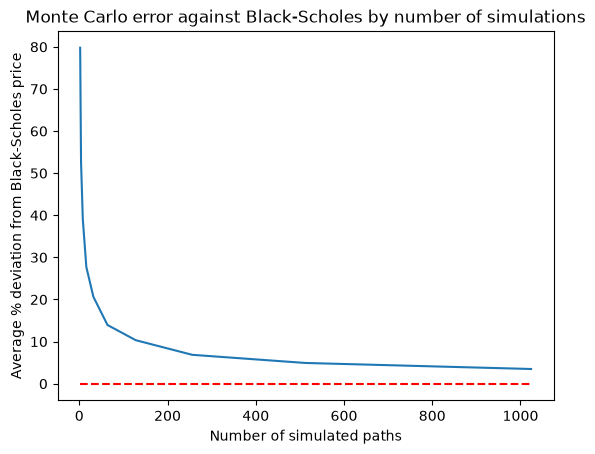

In [9]:
n_vals = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
mean_errors = []

for n in n_vals:
    error = 0
    
    for i in range(1000):
        option_value_estimate, confidence_bounds = MC_value_option(
            call=True,
            n_paths=n,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1,
            alpha=0.05
        )

        option_value_BS, _ = BlackScholes(
            call=True,
            S0=100,
            K=100,
            r=0.05,
            vol=0.2,
            T=1
        )

        error += 100 * abs(option_value_estimate - option_value_BS) / option_value_BS

    mean_error = error / 1000
    mean_errors.append(mean_error)


plt.figure()
plt.plot(n_vals, mean_errors)
plt.title("Monte Carlo error against Black-Scholes by number of simulations")
plt.xlabel("Number of simulated paths")
plt.ylabel("Average % deviation from Black-Scholes price")
plt.plot(n_vals, np.zeros(len(n_vals)), c='r', linestyle='--')
plt.show()

We observe the expected decreasing trend, however the rate of convergence is not clear. When introducing a $\log$ transform to the $x$ and $y$ axes, we observe approximately linear convergence:

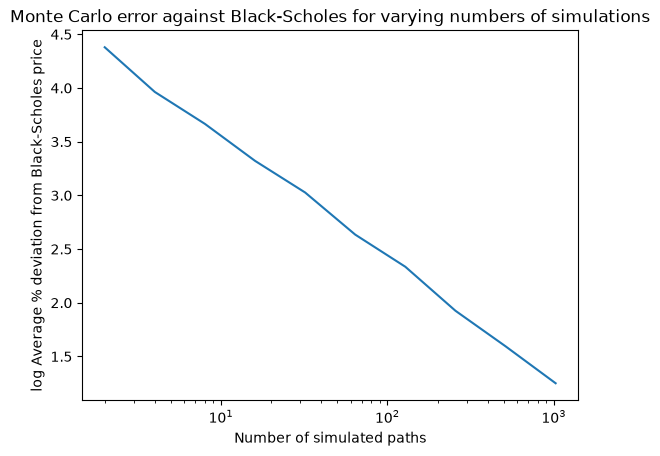

In [10]:
log_mean_errors = np.log(np.array(mean_errors))

plt.figure()
plt.plot(n_vals, log_mean_errors)
plt.title("Monte Carlo error against Black-Scholes for varying numbers of simulations")
plt.xlabel("Number of simulated paths")
plt.ylabel("log Average % deviation from Black-Scholes price")
plt.xscale('log')
plt.show()

Let $e^{(k)} = |V_{BS} - V_{MC}^{(k)}|$ represent the mean Monte Carlo valuation error with $k$ simulations (against Black-Scholes). Then, based on our observation,

$$
\log{(e^{(k)})} \approx c_0 + c_1\log{k} \implies e^{(k)} = e^{c_0}(e^{\log{k}})^{c_1} = e^{c_0}k^{c_1} = Ck^{c_1}
$$

for some $C > 0$.

So, we can estimate the gradient of the line $(c_1)$ to get an approximation for the rate of convergence. We use the segment of the line between 2 and 512 paths, as this is very close to straight.

In [12]:
c1_est = (log_mean_errors[8] - log_mean_errors[0]) / (np.log(512) - np.log(2))

print(f"Gradient estimate: {round(c1_est, 4)}")

Gradient estimate: -0.5022


The result is
$$
c_1 \approx -\frac{1}{2}.
$$
This implies that our error converges as $O(n^{-\frac{1}{2}}) $, i.e. $O(\frac{1}{\sqrt{n}})$.